## 8. Multicollinearity And VIF

Complete rows for the correlation and VIF step: 62 (2010Q3 to 2025Q4)


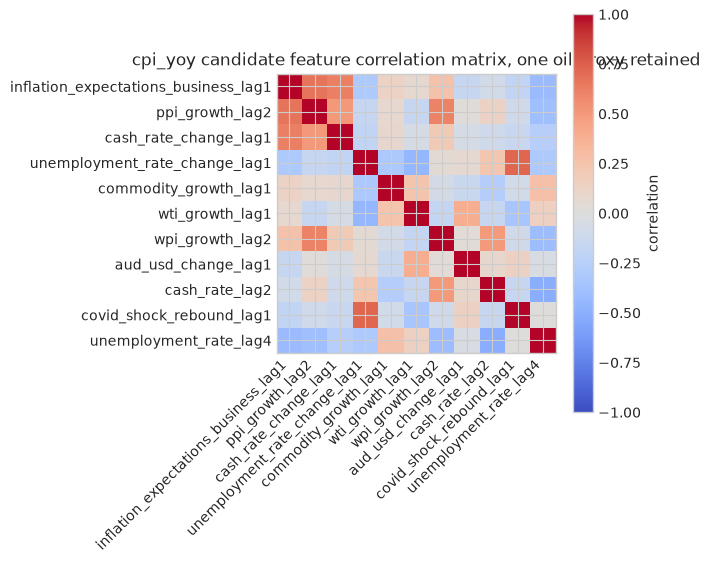

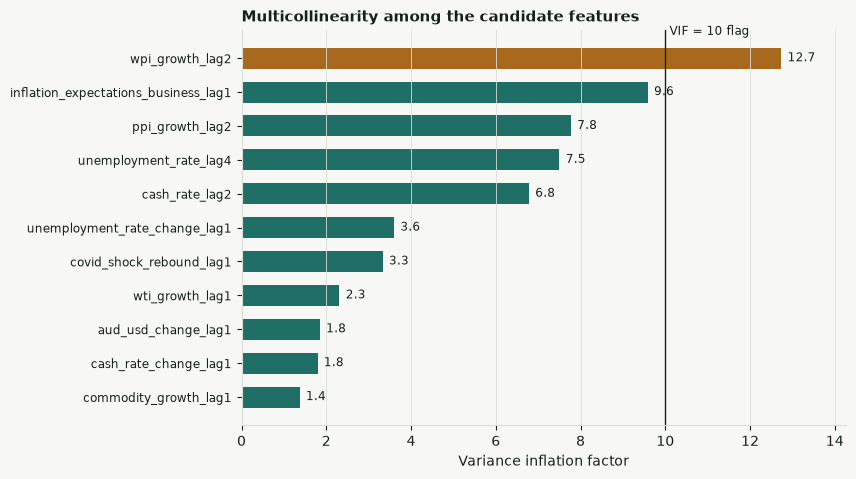

CPI-family lag VIF diagnostic for autoregressive headline terms and trimmed-mean CPI lag.

CPI-family lag VIFs: trimmed_mean_cpi_yoy_lag1 3.43, cpi_yoy_lag1 2.49, cpi_yoy_lag4 1.85


In [10]:
def lag_base_name(feature: str) -> str:
    return re.sub(r'_lag\d+$', '', feature)


def feature_lag(feature: str | None) -> int | None:
    if feature is None:
        return None
    match = re.search(r'_lag(\d+)$', feature)
    return int(match.group(1)) if match else None


availability_assumptions = pd.read_csv(AVAILABILITY_PATH)
availability_assumptions['assumed_min_safe_lag_quarters'] = availability_assumptions['assumed_min_safe_lag_quarters'].astype(int)

# Notebook-only rate-change features inherit the release-lag assumption of their
# source rate level; no exact release dates are fabricated here.
for source_col in RATE_CHANGE_LAG_MAP:
    change_col = f'{source_col}_change'
    if change_col in EXTERNAL_BASE_COLS and change_col not in set(availability_assumptions['variable']) and source_col in set(availability_assumptions['variable']):
        source_row = availability_assumptions.loc[availability_assumptions['variable'] == source_col].iloc[0].copy()
        source_row['variable'] = change_col
        source_row['source_family'] = f"derived {source_row['source_family']} change"
        source_row['assumption_note'] = f"Inherits {source_col} release-lag assumption; transformed as percentage-point change."
        availability_assumptions = pd.concat([availability_assumptions, source_row.to_frame().T], ignore_index=True)

missing_availability_metadata = sorted(set(EXTERNAL_BASE_COLS) - set(availability_assumptions['variable']))
if missing_availability_metadata:
    raise ValueError(f'Missing availability metadata for: {missing_availability_metadata}')

availability_assumptions['assumed_min_safe_lag_quarters'] = availability_assumptions['assumed_min_safe_lag_quarters'].astype(int)
availability_lookup = availability_assumptions.set_index('variable')['assumed_min_safe_lag_quarters'].to_dict()
lagged_feature_bases = {lag_base_name(feature) for feature in EXTERNAL_LAGGED_FEATURES}

def min_safe_lag_for_base(base: str) -> int:
    return int(availability_lookup.get(base, 0))


def build_target_candidate_artifacts(
    target: str,
    best_predictive: pd.DataFrame,
    ccf_frame: pd.DataFrame,
    granger_lags: pd.DataFrame,
    show_diagnostics: bool = True,
) -> dict[str, object]:
    target_best_lag_lookup = dict(zip(best_predictive['variable'], best_predictive['lag_quarters']))

    def target_ccf_corr_at_lag(variable: str, lag: int | None) -> float:
        if lag is None:
            return np.nan
        match = ccf_frame.loc[(ccf_frame['variable'] == variable) & (ccf_frame['lag_quarters'] == lag), 'correlation']
        return float(match.iloc[0]) if not match.empty else np.nan

    def target_granger_p_at_lag(variable: str, lag: int | None) -> float:
        if lag is None or granger_lags.empty:
            return np.nan
        match = granger_lags.loc[(granger_lags['variable'] == variable) & (granger_lags['lag_quarters'] == lag), 'granger_p_value']
        return float(match.iloc[0]) if not match.empty else np.nan

    def choose_safe_lagged_feature(base: str, matching_features: list[str]) -> str | None:
        min_safe_lag = min_safe_lag_for_base(base)
        safe_features = [feature for feature in matching_features if (feature_lag(feature) or -1) >= min_safe_lag]
        if not safe_features:
            return None
        preferred_lag = max(int(target_best_lag_lookup.get(base, feature_lag(safe_features[0]) or min_safe_lag)), min_safe_lag)
        exact = [feature for feature in safe_features if feature_lag(feature) == preferred_lag]
        if exact:
            return exact[0]
        at_or_above_preferred = [feature for feature in safe_features if (feature_lag(feature) or 99) >= preferred_lag]
        return sorted(at_or_above_preferred or safe_features, key=lambda feature: feature_lag(feature) or 99)[0]

    all_lagged_bases = sorted({lag_base_name(feature) for feature in EXTERNAL_LAGGED_FEATURES})
    base_screen_order = [base for base in EXOGENOUS_CANDIDATE_BASE_PRIORITY if base in all_lagged_bases]
    base_screen_order += [base for base in all_lagged_bases if base not in base_screen_order and base not in cpi_family_exclusion_cols]

    feature_choices = []
    for base in base_screen_order:
        matching_features = [feature for feature in EXTERNAL_LAGGED_FEATURES if lag_base_name(feature) == base]
        chosen = choose_safe_lagged_feature(base, matching_features)
        if chosen is not None and df[chosen].notna().mean() >= 0.50:
            feature_choices.append(chosen)

    candidate_features = list(dict.fromkeys(feature_choices))

    oil_pair_decision = pd.DataFrame()
    vif_features = candidate_features.copy()
    if 'wti_growth_lag1' in candidate_features and 'brent_growth_lag1' in candidate_features:
        wti_coverage = float(coverage.set_index('variable').loc['wti_growth', 'coverage_pct'])
        brent_coverage = float(coverage.set_index('variable').loc['brent_growth', 'coverage_pct'])
        preferred_oil_feature = 'wti_growth_lag1' if wti_coverage >= brent_coverage else 'brent_growth_lag1'
        dropped_oil_feature = 'brent_growth_lag1' if preferred_oil_feature == 'wti_growth_lag1' else 'wti_growth_lag1'
        vif_features = [feature for feature in vif_features if feature != dropped_oil_feature]
        oil_pair_decision = pd.DataFrame([{
            'target': target,
            'preferred_oil_feature_for_primary_vif': preferred_oil_feature,
            'alternative_oil_feature': dropped_oil_feature,
            'wti_growth_coverage_pct': wti_coverage,
            'brent_growth_coverage_pct': brent_coverage,
            'reason': 'WTI and Brent growth are alternative oil-price proxies; include at most one in an Elastic Net specification.',
        }])

    coverage_by_variable = coverage.set_index('variable')
    candidate_feature_diagnostics = pd.DataFrame([
        {
            'target': target,
            'candidate_feature': feature,
            'variable': lag_base_name(feature),
            'candidate_lag': feature_lag(feature),
            'candidate_corr': target_ccf_corr_at_lag(lag_base_name(feature), feature_lag(feature)),
            'candidate_abs_corr': abs(target_ccf_corr_at_lag(lag_base_name(feature), feature_lag(feature))),
            'candidate_granger_p_value': target_granger_p_at_lag(lag_base_name(feature), feature_lag(feature)),
            'best_ccf_lag': int(target_best_lag_lookup.get(lag_base_name(feature), np.nan)) if lag_base_name(feature) in target_best_lag_lookup else np.nan,
            'best_ccf_corr': target_ccf_corr_at_lag(lag_base_name(feature), int(target_best_lag_lookup.get(lag_base_name(feature), 1))) if lag_base_name(feature) in target_best_lag_lookup else np.nan,
            'available_observations': int(coverage_by_variable.loc[lag_base_name(feature), 'available_observations']) if lag_base_name(feature) in coverage_by_variable.index else np.nan,
            'coverage_pct': float(coverage_by_variable.loc[lag_base_name(feature), 'coverage_pct']) if lag_base_name(feature) in coverage_by_variable.index else np.nan,
        }
        for feature in candidate_features
    ])

    candidate_matrix = df[vif_features].apply(pd.to_numeric, errors='coerce').dropna()
    candidate_sample_summary = {'target': target, 'complete_rows_for_corr_vif': int(len(candidate_matrix))}
    if not candidate_matrix.empty:
        candidate_quarters = df.loc[candidate_matrix.index, 'quarter_period']
        candidate_sample_summary.update({'start_quarter': str(candidate_quarters.iloc[0]), 'end_quarter': str(candidate_quarters.iloc[-1])})
    candidate_sample_summary = pd.DataFrame([candidate_sample_summary])

    corr_matrix = pd.DataFrame()
    if len(vif_features) >= 2 and len(candidate_matrix) >= 24:
        corr_matrix = candidate_matrix.corr()
        vif_rows = []
        vif_input = candidate_matrix.astype(float)
        for index, feature in enumerate(vif_input.columns):
            vif_rows.append({'candidate_feature': feature, 'vif': variance_inflation_factor(vif_input.values, index)})
        vif = pd.DataFrame(vif_rows).sort_values('vif', ascending=False)
    else:
        vif = pd.DataFrame({'candidate_feature': vif_features, 'vif': np.nan, 'note': 'not enough candidate features or complete rows for VIF'})

    if show_diagnostics:
        if not oil_pair_decision.empty:
            pass
        print(f"Complete rows for the correlation and VIF step: {int(candidate_sample_summary['complete_rows_for_corr_vif'].iloc[0])} "
              f"({candidate_sample_summary['start_quarter'].iloc[0]} to {candidate_sample_summary['end_quarter'].iloc[0]})")
        if not corr_matrix.empty:
            fig, ax = plt.subplots(figsize=(max(6, 0.6 * len(vif_features)), max(5, 0.55 * len(vif_features))))
            image = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
            ax.set_xticks(range(len(corr_matrix.columns)))
            ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
            ax.set_yticks(range(len(corr_matrix.index)))
            ax.set_yticklabels(corr_matrix.index)
            ax.set_title(f'{target} candidate feature correlation matrix, one oil proxy retained')
            fig.colorbar(image, ax=ax, label='correlation')
            fig.tight_layout()
            plt.show()
        with plt.rc_context(BOOK_STYLE):
            v = vif.sort_values("vif").reset_index(drop=True)
            fig, ax = plt.subplots(figsize=(7.8, 0.34 * len(v) + 1.4))
            ax.barh(v.index, v["vif"], color=np.where(v["vif"] >= 10, HIGHLIGHT, ACCENT), height=0.62)
            ax.axvline(10, color=INK, linewidth=1.0)
            ax.text(10.1, len(v) - 0.4, "VIF = 10 flag", fontsize=8.5, va="bottom")
            for y, r in v.iterrows():
                ax.text(r["vif"] + 0.15, y, f"{r['vif']:.1f}", va="center", fontsize=8.5)
            ax.set_yticks(v.index, v["candidate_feature"], fontsize=8.6)
            ax.set_xlim(0, max(14, v["vif"].max() * 1.12))
            ax.set_xlabel("Variance inflation factor")
            ax.set_title("Multicollinearity among the candidate features", loc="left", fontsize=11, fontweight="bold")
            ax.grid(axis="y", visible=False)
            plt.show()

    return {
        'target': target,
        'candidate_features': candidate_features,
        'vif_features': vif_features,
        'oil_pair_decision': oil_pair_decision,
        'candidate_feature_diagnostics': candidate_feature_diagnostics,
        'candidate_matrix': candidate_matrix,
        'candidate_sample_summary': candidate_sample_summary,
        'corr_matrix': corr_matrix,
        'vif': vif,
        'best_lag_lookup': target_best_lag_lookup,
        'ccf_corr_at_lag': target_ccf_corr_at_lag,
        'granger_p_at_lag': target_granger_p_at_lag,
        'choose_safe_lagged_feature': choose_safe_lagged_feature,
    }


EXOGENOUS_CANDIDATE_BASE_PRIORITY = [
    'inflation_expectations_business',
    'ppi_growth',
    'cash_rate_change',
    'unemployment_rate_change',
    'commodity_growth',
    'wti_growth',
    'brent_growth',
    'wpi_growth',
    'aud_usd_change',
    'household_spending_growth',
]

headline_candidate_artifacts = build_target_candidate_artifacts(
    TARGET,
    best_predictive_ccf,
    ccf,
    granger_lag_results,
    show_diagnostics=True,
)
candidate_features = headline_candidate_artifacts['candidate_features']
vif_features = headline_candidate_artifacts['vif_features']
oil_pair_decision = headline_candidate_artifacts['oil_pair_decision']
candidate_feature_diagnostics = headline_candidate_artifacts['candidate_feature_diagnostics']
candidate_matrix = headline_candidate_artifacts['candidate_matrix']
vif = headline_candidate_artifacts['vif']
ccf_corr_at_lag = headline_candidate_artifacts['ccf_corr_at_lag']
granger_p_at_lag = headline_candidate_artifacts['granger_p_at_lag']

cpi_family_vif_features = [feature for feature in ['cpi_yoy_lag1', 'cpi_yoy_lag4', 'trimmed_mean_cpi_yoy_lag1'] if feature in df_model.columns]
cpi_family_vif_input = df[cpi_family_vif_features].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
if len(cpi_family_vif_features) >= 2 and len(cpi_family_vif_input) >= 24:
    cpi_family_standardized = (cpi_family_vif_input - cpi_family_vif_input.mean()) / cpi_family_vif_input.std(ddof=0)
    cpi_family_standardized = cpi_family_standardized.loc[:, cpi_family_standardized.nunique(dropna=True) > 1]
    cpi_family_vif_matrix = add_constant(cpi_family_standardized, has_constant='add')
    cpi_family_vif_rows = []
    for index, feature in enumerate(cpi_family_standardized.columns):
        cpi_family_vif_rows.append({
            'candidate_feature': feature,
            'observations': int(len(cpi_family_standardized)),
            'vif': variance_inflation_factor(cpi_family_vif_matrix.to_numpy(), index + 1),
        })
    cpi_family_vif = pd.DataFrame(cpi_family_vif_rows).sort_values('vif', ascending=False)
else:
    cpi_family_vif = pd.DataFrame({'candidate_feature': cpi_family_vif_features, 'observations': len(cpi_family_vif_input), 'vif': np.nan})

display(Markdown('CPI-family lag VIF diagnostic for autoregressive headline terms and trimmed-mean CPI lag.'))
print("CPI-family lag VIFs: " + ", ".join(f"{r.candidate_feature} {r.vif:.2f}" for r in cpi_family_vif.itertuples()))

**Interpretation.** Only one candidate feature crosses the conventional VIF=10 danger
threshold, `wpi_growth_lag2` at 12.7, and one more sits right at the edge: `inflation_expectations_business_lag1` at 9.6. Both are correlated with each other (r=0.665)
and with the cash-rate features (r=0.62–0.67), which is a real, if moderate, redundancy
problem: three of the strongest headline predictors are measuring overlapping information
about the same underlying price/policy cycle. This is the concrete justification for
regularizing at all in §4.2 Elastic Net: the $\ell_2$ penalty is specifically designed to
split credit between correlated features like these rather than letting an unregularized
fit arbitrarily favor one. The separate CPI-family lag check (`trimmed_mean_cpi_yoy_lag1`
VIF=3.427, `cpi_yoy_lag1` VIF=2.490, `cpi_yoy_lag4` VIF=1.854) is comfortably below the
threshold: the mild collinearity problem here is between the *external* macro features,
not between CPI's own lags.